# GKBA vs exact (Krylov) — spin density comparison

Compares the GKBA (pos-rep, static and dynamic lead GF) against the exact
single-particle propagation $C(t+\delta t) = e^{-iH\delta t}\,C(t)\,e^{iH\delta t}$
for two setups:

- **1 lead** (left lead only)
- **2 leads** (left + right)

Same parameters and initial conditions in all cases: quench from the decoupled
equilibrium state at $t=0$, then propagate with precessing spins.

In [56]:
using LinearAlgebra, DifferentialEquations
using PyPlot
using LaTeXStrings
import GKBA: build_hs, build_heα_posrep, build_hseα_posrep, build_hseα,
             init_gkba_posrep, init_egkba_posrep,
             eom_gkba_posrep!, eom_egkba_posrep!,
             init_gkba, init_egkba,
             eom_gkba!, eom_egkba!,
             init_gkba_wbl, eom_gkba_wbl!,
             compute_observables!, unpack!,
             PrecSpin, update!, fermi, K_BOLTZMAN
import GKBA: σ_x, σ_y, σ_z

In [2]:
rc("text", usetex=true)
rc("font", family="serif")
rc("text.latex", preamble=raw"\usepackage{amsmath}")
rc("font", size=18)
rc("axes", labelsize=22, titlesize=22)
rc("xtick", labelsize=18)
rc("ytick", labelsize=18)
rc("legend", fontsize=16)

## Common parameters

This notebook compares three lead descriptions under the same driven-spin setup:

- `Exact`: explicit finite leads in position representation.
- `pos-rep`: GKBA/eGKBA with the lead kept in real space.
- `k-rep`: GKBA/eGKBA with the lead diagonalized into momentum modes.
- `WBL`: GKBA in the wide-band limit using Ozaki poles.

The goal is not that all finite-`nk` curves coincide exactly at once. Rather, the
comparison checks whether they approach the same physics when the lead description
and the numerical resolution are chosen consistently.

In [88]:
nx, ny  = 2, 1
ns      = nx * ny
nk      = 60       # lead sites (pos-rep)
nk_krep = 60       # BZ k-points (k-rep)
nk_wbl  = 20       # Ozaki pole parameter (n_oz = nk_wbl*nσ = 40 poles)
nσ      = 2
γ       = 1.0
γso     = 0.0
γc      = 1.0
j_sd    = 0.1
Temp    = 300.0
β       = 1.0 / (K_BOLTZMAN * Temp)

t_0     = 0.0
dt      = 0.1
t_end   = 100.0
ts      = collect(t_0 + dt : dt : t_end)

# Precessing spins
theta_1 = 20.0
phi_1   = 0.0
period  = 5.0

# WBL coupling turn-on envelope (same choice as the reference driver)
stepp(t; ti = 3, to = 25) = 1 / (1 + exp(-(t - to) / ti))
stepp(t;ti=50) = t < ti ? sin((pi/2)*t/ti)^4 : 1
Ne = nk * nσ   # lead DOF (pos-rep)
Ns = ns * nσ   # system DOF

4

In [89]:
# times = 0.0:0.1:100
# plt.plot(times,stepp.(times))
# plt.plot(times,stepp2.(times))

## Helper functions

Two implementation details are important for the comparison:

1. The coupling is turned on smoothly through `stepp(t)` in every method.
   In `pos-rep` and `k-rep` this multiplies the explicit tunneling matrix `hse`; in
   `WBL` the same idea appears through the effective coupling scale `s_\alpha(t)`.
2. For the `k-rep` single-lead helper we still initialize two leads and then set the
   right-lead coupling to zero, because the current backend helper assumes two lead
   slots internally.

In [90]:
# Precessing spin initializer
function make_spins(nx; theta=theta_1, phi=phi_1, T=period)
    [PrecSpin(i; theta_zero=theta, phi_zero=phi, T=T) for i in 1:nx]
end

function vm_at(t; nx=nx)
    ps = make_spins(nx)
    vm = zeros(Float64, nx, 3)
    for p in ps; update!(p, t); vm[p.i, :] .= p.s; end
    vm
end

# Build the exact single-particle Hamiltonian used in the benchmark propagation.
# Layout: lead_L | [lead_R] | system, with the same smooth switch-on applied to
# the explicit system-lead tunneling block used in the finite-lead representation.
function build_htot(t, nα)
    vm   = vm_at(t)
    hs   = build_hs(vm, nx, ny, γ, γso, j_sd)
    heα  = build_heα_posrep(zeros(nα), γ, nk, nσ, nα)
    hseα = build_hseα_posrep(ns, γc, nk, nσ, nα) .* stepp(t)
    dim  = nα * Ne + Ns
    H    = zeros(ComplexF64, dim, dim)
    # diagonal blocks
    for α in 1:nα
        r = (α-1)*Ne+1 : α*Ne
        H[r, r] = heα[:, :, α]
    end
    rS = nα*Ne+1 : nα*Ne+Ns
    H[rS, rS] = hs
    # coupling blocks
    for α in 1:nα
        r = (α-1)*Ne+1 : α*Ne
        H[rS, r] = hseα[:, :, α]
        H[r, rS] = hseα[:, :, α]'
    end
    return H, nα*Ne+1 : nα*Ne+Ns   # H and system index range rS
end

# Initial correlation matrix for the decoupled equilibrium state.
# System and leads are populated separately before the coupling is turned on.
function init_C(nα)
    vm0  = vm_at(0.0)
    hs0  = build_hs(vm0, nx, ny, γ, γso, j_sd)
    heα0 = build_heα_posrep(zeros(nα), γ, nk, nσ, nα)
    dim  = nα * Ne + Ns
    C    = zeros(ComplexF64, dim, dim)
    # system block
    εs, Us = eigen(hs0)
    C[nα*Ne+1:end, nα*Ne+1:end] = Us * Diagonal(fermi.(εs * β)) * Us'
    # lead blocks
    for α in 1:nα
        r = (α-1)*Ne+1 : α*Ne
        εe, Ue = eigen(heα0[:, :, α])
        C[r, r] = Ue * Diagonal(fermi.(εe * β)) * Ue'
    end
    return C
end

# One exact step: C ← exp(-iH dt) C exp(iH dt)
function exact_step!(C, H, dt)
    U  = exp(-1im * dt * H)
    C .= U * C * U'
end

# Observables extracted directly from the single-particle correlation matrix.
σs = [σ_x, σ_y, σ_z]
sblock(site, nα) = nα*Ne + (2site-1) : nα*Ne + 2site

function sden_from_C(C, nα)
    [real(tr(C[sblock(s, nα), sblock(s, nα)] * σs[x]))
     for s in 1:ns, x in 1:3]
end

function scurr_from_C(C, H, nα, site, α)
    # spin current from system site → lead α edge (coupling at k-modes 1,2)
    rL  = (α-1)*Ne+1 : (α-1)*Ne+2
    rSi = sblock(site, nα)
    [2 * imag(tr(H[rSi, rL] * C[rL, rSi] * σs[x])) for x in 1:3]
end

scurr_from_C (generic function with 1 method)

## Exact propagation

In [91]:
function run_exact(nα)
    C    = init_C(nα)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)     # spin current to lead 1
    t    = t_0
    for (n, tt) in enumerate(ts)
        H, rS = build_htot(t + 0.5dt, nα)   # midpoint rule
        exact_step!(C, H, dt)
        C .= 0.5 * (C + C')                 # enforce Hermiticity
        t  = tt
        H_now, _ = build_htot(tt, nα)
        sden[n, :, :] = sden_from_C(C, nα)
        sc[n, :]      = scurr_from_C(C, H_now, nα, 1, 1)
    end
    sden, sc
end

run_exact (generic function with 1 method)

## GKBA propagation (pos-rep, k-rep, and WBL)

The three GKBA branches differ mostly in how the lead is represented, not in the
driving protocol:

- `pos-rep`: the lead is a finite tight-binding chain.
- `k-rep`: the same lead is expressed in its mode basis.
- `WBL`: the lead memory is compressed into an effective wide-band description.

For fairness, all runs use the same spin precession and the same adiabatic switch-on.
A remaining mismatch between `pos-rep` and `k-rep` at finite `nk` should therefore be
read mainly as a discretization / representation effect, not as a different protocol.

In [92]:
function run_gkba_posrep(nα)
    vm0      = vm_at(0.0)
    dv, ov   = init_gkba_posrep(; nx, ny, nk, γ, γso, γc, j_sd, Temp,
                                  vm_i1x=vm0, nα=nα,
                                  μ_α=zeros(nα), ϵ0α=zeros(nα))
    # In the finite real-space lead description we modulate the explicit tunneling
    # matrix itself, hse(t) = stepp(t) * hse.
    dv.hseα_ikα .*= stepp(t_0)
    dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
    prob     = ODEProblem(eom_gkba_posrep!, dv.rkvec, (t_0, t_end), dv)
    integ    = init(prob, RK4(); dt=dt, save_everystep=false,
                   adaptive=false, dense=false)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)
    ps   = make_spins(nx)
    for (n, tt) in enumerate(ts)
        step!(integ, dt, true)
        unpack!(dv, integ.u)
        compute_observables!(ov, dv)
        for p in ps; update!(p, tt); dv.vm_i1x[p.i, :] .= p.s; end
        dv.hs_ij = build_hs(dv.vm_i1x, nx, ny, γ, γso, j_sd)
        # Rebuild the time-dependent coupling after updating the spin texture.
        dv.hseα_ikα = build_hseα_posrep(ns, γc, nk, nσ, nα) .* stepp(tt)
        dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
        sden[n, :, :] = ov.sden_i1x
        sc[n, :]      = ov.scurr_xα[:, 1]
    end
    sden, sc
end

function run_egkba_posrep(nα)
    vm0      = vm_at(0.0)
    dv, ov   = init_egkba_posrep(; nx, ny, nk, γ, γso, γc, j_sd, Temp,
                                   vm_i1x=vm0, nα=nα,
                                   μ_α=zeros(nα), ϵ0α=zeros(nα))
    dv.hseα_ikα .*= stepp(t_0)
    dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
    prob     = ODEProblem(eom_egkba_posrep!, dv.rkvec, (t_0, t_end), dv)
    integ    = init(prob, RK4(); dt=dt, save_everystep=false,
                   adaptive=false, dense=false)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)
    ps   = make_spins(nx)
    for (n, tt) in enumerate(ts)
        step!(integ, dt, true)
        unpack!(dv, integ.u)
        compute_observables!(ov, dv)
        for p in ps; update!(p, tt); dv.vm_i1x[p.i, :] .= p.s; end
        dv.hs_ij = build_hs(dv.vm_i1x, nx, ny, γ, γso, j_sd)
        dv.hseα_ikα = build_hseα_posrep(ns, γc, nk, nσ, nα) .* stepp(tt)
        dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
        sden[n, :, :] = ov.sden_i1x
        sc[n, :]      = ov.scurr_xα[:, 1]
    end
    sden, sc
end

run_egkba_posrep (generic function with 1 method)

In [93]:
function run_gkba_krep(nα; nk_k=nk_krep)
    vm0         = vm_at(0.0)
    nα_eff      = max(nα, 2)   # backend helper assumes two lead slots; decouple lead 2 below
    single_lead = (nα == 1)
    dv, ov      = init_gkba(; nx, ny, nk=nk_k, γ, γso, γc, j_sd, Temp,
                              vm_i1x=vm0, nα=nα_eff,
                              μ_α=zeros(nα_eff), ϵ0α=zeros(nα_eff))
    # In k-representation the same switch-on multiplies the tunneling amplitudes to
    # all occupied lead modes.
    dv.hseα_ikα .*= stepp(t_0)
    dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
    if single_lead
        dv.hseα_ikα[:, :, 2] .= 0.0
        dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
    end
    prob     = ODEProblem(eom_gkba!, dv.rkvec, (t_0, t_end), dv)
    integ    = init(prob, RK4(); dt=dt, save_everystep=false,
                   adaptive=false, dense=false)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)
    ps   = make_spins(nx)
    for (n, tt) in enumerate(ts)
        step!(integ, dt, true)
        unpack!(dv, integ.u)
        compute_observables!(ov, dv)
        for p in ps; update!(p, tt); dv.vm_i1x[p.i, :] .= p.s; end
        dv.hs_ij = build_hs(dv.vm_i1x, nx, ny, γ, γso, j_sd)
        dv.hseα_ikα = build_hseα(ns, γc, nk_k, nσ, nα_eff) .* stepp(tt)
        if single_lead
            dv.hseα_ikα[:, :, 2] .= 0.0
        end
        dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
        sden[n, :, :] = ov.sden_i1x
        sc[n, :]      = ov.scurr_xα[:, 1]
    end
    sden, sc
end

function run_egkba_krep(nα; nk_k=nk_krep)
    vm0         = vm_at(0.0)
    nα_eff      = max(nα, 2)   # k-rep helper assumes two leads; decouple lead 2 below
    single_lead = (nα == 1)
    dv, ov      = init_egkba(; nx, ny, nk=nk_k, γ, γso, γc, j_sd, Temp,
                               vm_i1x=vm0, nα=nα_eff,
                               μ_α=zeros(nα_eff), ϵ0α=zeros(nα_eff))
    dv.hseα_ikα .*= stepp(t_0)
    dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
    if single_lead
        dv.hseα_ikα[:, :, 2] .= 0.0
        dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
    end
    prob     = ODEProblem(eom_egkba!, dv.rkvec, (t_0, t_end), dv)
    integ    = init(prob, RK4(); dt=dt, save_everystep=false,
                   adaptive=false, dense=false)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)
    ps   = make_spins(nx)
    for (n, tt) in enumerate(ts)
        step!(integ, dt, true)
        unpack!(dv, integ.u)
        compute_observables!(ov, dv)
        for p in ps; update!(p, tt); dv.vm_i1x[p.i, :] .= p.s; end
        dv.hs_ij = build_hs(dv.vm_i1x, nx, ny, γ, γso, j_sd)
        dv.hseα_ikα = build_hseα(ns, γc, nk_k, nσ, nα_eff) .* stepp(tt)
        if single_lead
            dv.hseα_ikα[:, :, 2] .= 0.0
        end
        dv.heαs_kαi .= permutedims(conj.(dv.hseα_ikα), (2, 3, 1))
        sden[n, :, :] = ov.sden_i1x
        sc[n, :]      = ov.scurr_xα[:, 1]
    end
    sden, sc
end

run_egkba_krep (generic function with 1 method)

In [94]:
function run_gkba_wbl(nα; nk_w=nk_wbl)
    vm0    = vm_at(0.0)
    dv, ov = init_gkba_wbl(; nx, ny, nk=nk_w, γ, γso, γc, j_sd, Temp,
                             vm_i1x=vm0, nα=nα)
    # In WBL the same physical switch-on appears through the effective coupling scale
    # s_α(t), not through an explicit finite lead tunneling matrix.
    dv.s_α .= stepp(t_0)
    prob   = ODEProblem(eom_gkba_wbl!, dv.rkvec, (t_0, t_end), dv)
    integ  = init(prob, RK4(); dt=dt, save_everystep=false,
                 adaptive=true, dense=false)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)
    ps   = make_spins(nx)
    for (n, tt) in enumerate(ts)
        step!(integ, dt, true)
        unpack!(dv, integ.u)
        compute_observables!(ov, dv)
        for p in ps; update!(p, tt); dv.vm_i1x[p.i, :] .= p.s; end
        dv.hs_ij = build_hs(dv.vm_i1x, nx, ny, γ, γso, j_sd)
        dv.s_α .= stepp(tt)
        sden[n, :, :] = ov.sden_i1x
        sc[n, :]      = ov.scurr_xα[:, 1]
    end
    sden, sc
end

run_gkba_wbl (generic function with 1 method)

---
## Section 1: 1 lead

Left lead only (`nα = 1`).

In [95]:
println("Running exact (1 lead)...")
@time sd_ex1, sc_ex1 = run_exact(1)

println("Running GKBA pos-rep (1 lead)...")
@time sd_gk1, sc_gk1 = run_gkba_posrep(1)

println("Running eGKBA pos-rep (1 lead)...")
@time sd_eg1, sc_eg1 = run_egkba_posrep(1)

println("Running GKBA k-rep (1 lead)...")
@time sd_gkk1, sc_gkk1 = run_gkba_krep(1)

println("Running eGKBA k-rep (1 lead)...")
@time sd_egk1, sc_egk1 = run_egkba_krep(1)

println("Running GKBA WBL (1 lead)...")
@time sd_wbl1, sc_wbl1 = run_gkba_wbl(1)

println("Done.")

Running exact (1 lead)...
 12.357488 seconds (2.50 M allocations: 38.967 GiB, 17.22% gc time, 3.96% compilation time)
Running GKBA pos-rep (1 lead)...
  2.602976 seconds (57.75 M allocations: 2.011 GiB, 9.53% gc time, 0.24% compilation time)
Running eGKBA pos-rep (1 lead)...
 28.589156 seconds (57.78 M allocations: 3.947 GiB, 1.71% gc time)
Running GKBA k-rep (1 lead)...
  3.972495 seconds (115.59 M allocations: 3.985 GiB, 12.78% gc time, 12.22% compilation time)
Running eGKBA k-rep (1 lead)...
  8.588663 seconds (115.62 M allocations: 7.855 GiB, 11.22% gc time, 5.49% compilation time)
Running GKBA WBL (1 lead)...
 71.644304 seconds (2.41 G allocations: 82.319 GiB, 13.49% gc time, 0.07% compilation time)
Done.


### Spin density — site 1, 1 lead

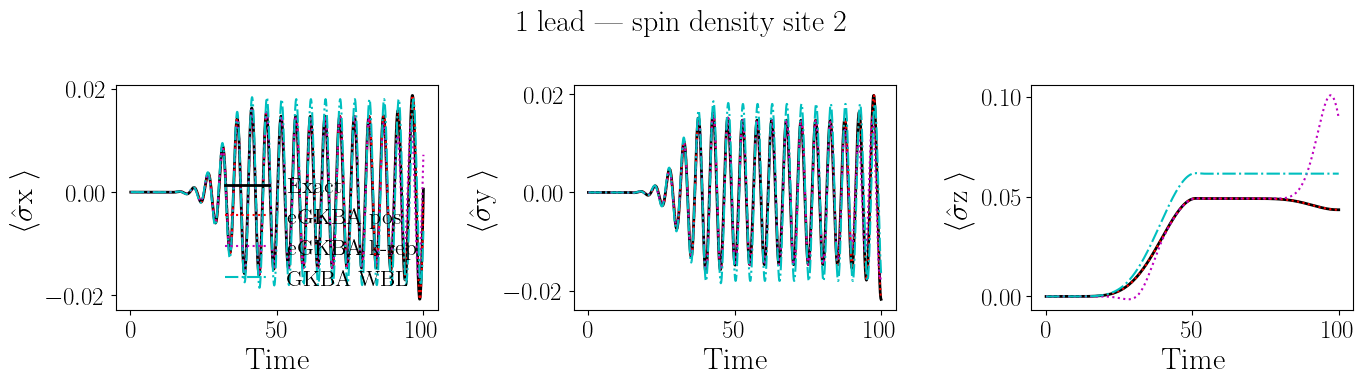

In [96]:
xlabels = ["x", "y", "z"]
site = 2

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sd_ex1[:, site, ix],  "k-",  lw=2,   label="Exact")
    #ax.plot(ts, sd_gk1[:, site, ix],  "b--", lw=1.5, label="GKBA pos")
    ax.plot(ts, sd_eg1[:, site, ix],  "r:",  lw=1.5, label="eGKBA pos")
    #ax.plot(ts, sd_gkk1[:, site, ix], "g-.", lw=1.5, label="GKBA k-rep")
    ax.plot(ts, sd_egk1[:, site, ix], "m:",  lw=1.5, label="eGKBA k-rep")
    ax.plot(ts, sd_wbl1[:, site, ix], "c-.", lw=1.5, label="GKBA WBL")
    ax.set_xlabel(L"\rm{Time}")
    ax.set_ylabel(L"\langle\rm{\hat \sigma}" * "$(xlabels[ix]) " * L"\rangle")
    ix == 1 && ax.legend(frameon=false)
end
fig.suptitle("1 lead \u2014 spin density site $(site)")
plt.tight_layout()

### Spin current to lead 1 — 1 lead

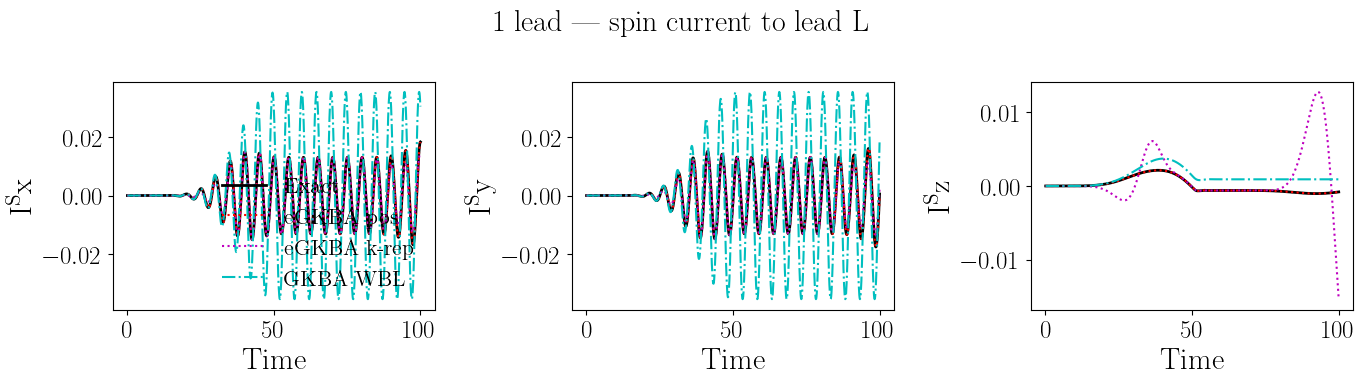

In [97]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sc_ex1[:, ix],  "k-",  lw=2,   label="Exact")
    #ax.plot(ts, sc_gk1[:, ix],  "b--", lw=1.5, label="GKBA pos")
    ax.plot(ts, sc_eg1[:, ix],  "r:",  lw=1.5, label="eGKBA pos")
    #ax.plot(ts, sc_gkk1[:, ix], "g-.", lw=1.5, label="GKBA k-rep")
    ax.plot(ts, sc_egk1[:, ix], "m:",  lw=1.5, label="eGKBA k-rep")
    ax.plot(ts, sc_wbl1[:, ix], "c-.", lw=1.5, label="GKBA WBL")
    ax.set_xlabel(L"\rm{Time}")
    ax.set_ylabel(L"\rm{I^{S}}" * "$(xlabels[ix]) ")
    ix == 1 && ax.legend(frameon=false)
end

fig.suptitle("1 lead \u2014 spin current to lead L")
plt.tight_layout()

---
## Section 2: 2 leads

Left + right leads (`nα = 2`).

In [98]:
println("Running exact (2 leads)...")
@time sd_ex2, sc_ex2 = run_exact(2)

println("Running GKBA pos-rep (2 leads)...")
@time sd_gk2, sc_gk2 = run_gkba_posrep(2)

println("Running eGKBA pos-rep (2 leads)...")
@time sd_eg2, sc_eg2 = run_egkba_posrep(2)

println("Running GKBA k-rep (2 leads)...")
@time sd_gkk2, sc_gkk2 = run_gkba_krep(2)

println("Running eGKBA k-rep (2 leads)...")
@time sd_egk2, sc_egk2 = run_egkba_krep(2)

println("Running GKBA WBL (2 leads)...")
@time sd_wbl2, sc_wbl2 = run_gkba_wbl(2)

println("Done.")

Running exact (2 leads)...
 20.203468 seconds (2.21 M allocations: 48.857 GiB, 13.89% gc time)
Running GKBA pos-rep (2 leads)...
  6.209518 seconds (115.35 M allocations: 3.995 GiB, 17.50% gc time)
Running eGKBA pos-rep (2 leads)...
 59.252915 seconds (115.38 M allocations: 7.864 GiB, 1.70% gc time)
Running GKBA k-rep (2 leads)...
  3.572372 seconds (115.36 M allocations: 3.975 GiB, 14.11% gc time)
Running eGKBA k-rep (2 leads)...
  8.295109 seconds (115.39 M allocations: 7.845 GiB, 11.87% gc time)
Running GKBA WBL (2 leads)...
147.506499 seconds (4.83 G allocations: 164.889 GiB, 13.23% gc time)
Done.


### Spin density — site 1, 2 leads

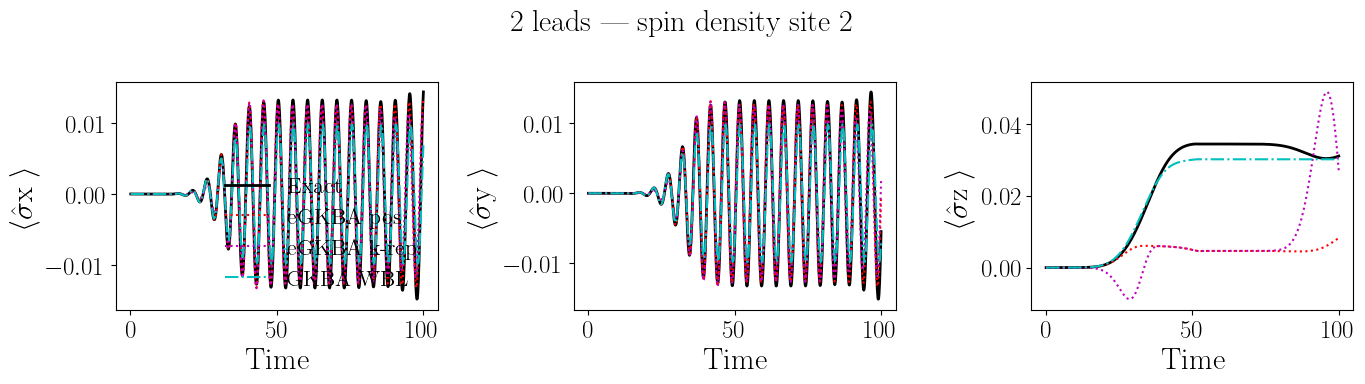

In [99]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sd_ex2[:, site, ix],  "k-",  lw=2,   label="Exact")
    #ax.plot(ts, sd_gk2[:, site, ix],  "b--", lw=1.5, label="GKBA pos")
    ax.plot(ts, sd_eg2[:, site, ix],  "r:",  lw=1.5, label="eGKBA pos")
    #ax.plot(ts, sd_gkk2[:, site, ix], "g-.", lw=1.5, label="GKBA k-rep")
    ax.plot(ts, sd_egk2[:, site, ix], "m:",  lw=1.5, label="eGKBA k-rep")
    ax.plot(ts, sd_wbl2[:, site, ix], "c-.", lw=1.5, label="GKBA WBL")
    ax.set_ylabel(L"\langle\rm{\hat \sigma}" * "$(xlabels[ix]) " * L"\rangle")
    ax.set_xlabel(L"\mathrm{Time}")
    ix == 1 && ax.legend(frameon=false)
end
fig.suptitle("2 leads \u2014 spin density site $(site)")
plt.tight_layout()

### Spin current to lead 1 — 2 leads

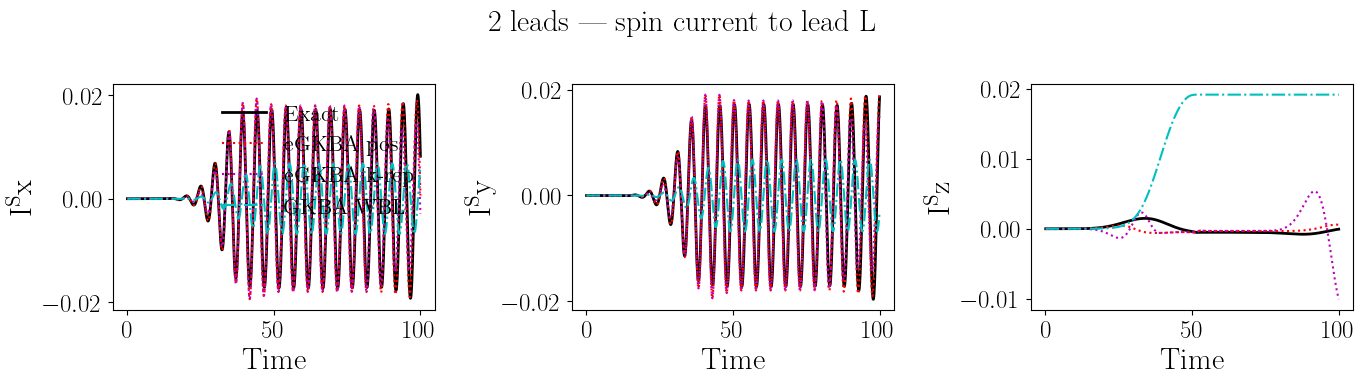

In [100]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sc_ex2[:, ix],  "k-",   lw = 2,   label="Exact")
    #ax.plot(ts, sc_gk2[:, ix],  "b--", lw=1.5, label="GKBA pos")
    ax.plot(ts, sc_eg2[:, ix],  "r:",   lw = 1.5, label="eGKBA pos")
    #ax.plot(ts, sc_gkk2[:, ix], "g-.", lw=1.5, label="GKBA k-rep")
    ax.plot(ts, sc_egk2[:, ix], "m:",   lw = 1.5, label="eGKBA k-rep")
    ax.plot(ts, sc_wbl2[:, ix]/(2pi), "c-.", lw=1.5, label="GKBA WBL")
    #ax.set_ylabel(L"\rm{I^{S}}"*"$(xlabels[ix])")
    #ax.set_ylabel(latexstring("I^{S}_{$(xlabels[ix])}"))
    ax.set_ylabel(L"\rm{I^{S}}" * "$(xlabels[ix]) ")
    ax.set_xlabel(L"\rm{Time}")
    ix == 1 && ax.legend(frameon=false)
end
fig.suptitle("2 leads \u2014 spin current to lead L")
plt.tight_layout()